# Data Visualization with Matplotlib and Additional Libraries  

## Introduction  

In this notebook, we will continue exploring data visualization using **Matplotlib** along with additional Python libraries such as **Pandas**, **NumPy**, and **Seaborn**. We will work with various types of plots to better understand, analyze, and present data effectively. This notebook is divided into three main sections, each covering different types of visualizations:

### Visualizations Covered  
1. **Basic Plots**:  
   - Area Plots, Histograms, and Bar Charts  
2. **Intermediate Plots**:  
   - Pie Charts, Box Plots, Scatter Plots, and Bubble Charts  
3. **Advanced Plots**:  
   - Waffle Charts, Word Clouds, and Regression Plots  

In addition, we will explore the use of the **Seaborn** library for more advanced visualizations, such as regression analysis.

### Dataset Description  
We will be working with data on **Immigration to Canada** from 1980 to 2013. The dataset comes from the United Nations' [International migration flows to and from selected countries](http://www.un.org/en/development/desa/population/migration/data/empirical2/migrationflows.shtml) - The 2015 revision. It contains annual data on both inflows and outflows of international migrants, categorized by place of birth, citizenship, or place of residence.

For this notebook, we will focus on the Canadian immigration data, analyzing patterns and trends over time.


## Table of Contents  

1. [Basic Plots](#basic-plots)<br>
   1.1. [Area Plot](#area-plot)<br>
   1.2. [Histogram](#histogram)<br> 
   1.3. [Bar Chart](#bar-chart)<br>  

2. [Intermediate Plots](#intermediate-plots)<br>
   2.1. [Pie Chart](#pie-chart)<br>
   2.2. [Box Plot](#box-plot)<br>
   2.3. [Scatter Plot](#scatter-plot)<br>
   2.4. [Bubble Chart](#bubble-chart)<br>

3. [Advanced Plots](#advanced-plots)<br>
   3.1. [Waffle Chart](#waffle-chart)<br>
   3.2. [Word Cloud](#word-cloud)<br>
   3.3. [Regression Plot](#regression-plot)<br>

4. [Conclusion](#conclusion)<br>

---

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.style.use('ggplot') # optional: for ggplot-like style
import matplotlib.patches as mpatches
%matplotlib inline 

import requests
import seaborn as sns
from PIL import Image
from wordcloud import WordCloud, STOPWORDS

# Load Data




In [2]:
df_can = pd.read_excel('https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DV0101EN/labs/Data_Files/Canada.xlsx',
                       sheet_name='Canada by Citizenship',
                       skiprows=range(20),
                       skipfooter=2
                      )

df_can.drop(['AREA', 'REG', 'DEV', 'Type', 'Coverage'], axis=1, inplace=True)

df_can.rename(columns={'OdName':'Country', 'AreaName':'Continent','RegName':'Region'}, inplace=True)

For consistency, ensure that all column labels of type string.

In [3]:
all(isinstance(column, str) for column in df_can.columns)

False

Notice how the above line of code returned *False* when we tested if all the column labels are of type **string**. So let's change them all to **string** type.


In [4]:
df_can.columns = list(map(str, df_can.columns))

all(isinstance(column, str) for column in df_can.columns)

True

In [5]:
df_can.set_index('Country', inplace=True)

df_can['Total'] = df_can.sum(axis=1, numeric_only=True)

df_can.head()

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,2,...,0,1,1,0,0,0,0,1,1,15


In [6]:
print('Data dimensions:', df_can.shape)

Data dimensions: (195, 38)


In [7]:
years = list(map(str, range(1980, 2014)))

## 1. Basic Plots <a id="basic-plots"></a>

### 1.1 Area Plot <a id="area-plot"></a>

Area plots are stacked by default. And to produce a stacked area plot, each column must be either all positive or all negative values (any NaN values will defaulted to 0). To produce an unstacked plot, pass `stacked=False`.

In [8]:
# Sort Values by Total columns
df_can.sort_values(['Total'], ascending=False, axis=0, inplace=True)

# Top 5 Countries
df_top5 = df_can.head()
df_top5 = df_top5[years].transpose()
df_top5.head()

Country,India,China,United Kingdom of Great Britain and Northern Ireland,Philippines,Pakistan
1980,8880,5123,22045,6051,978
1981,8670,6682,24796,5921,972
1982,8147,3308,20620,5249,1201
1983,7338,1863,10015,4562,900
1984,5704,1527,10170,3801,668


In [9]:
# Convert Index from string to integer
df_top5.index = df_top5.index.map(int)
df_top5.index

Index([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013],
      dtype='int64')

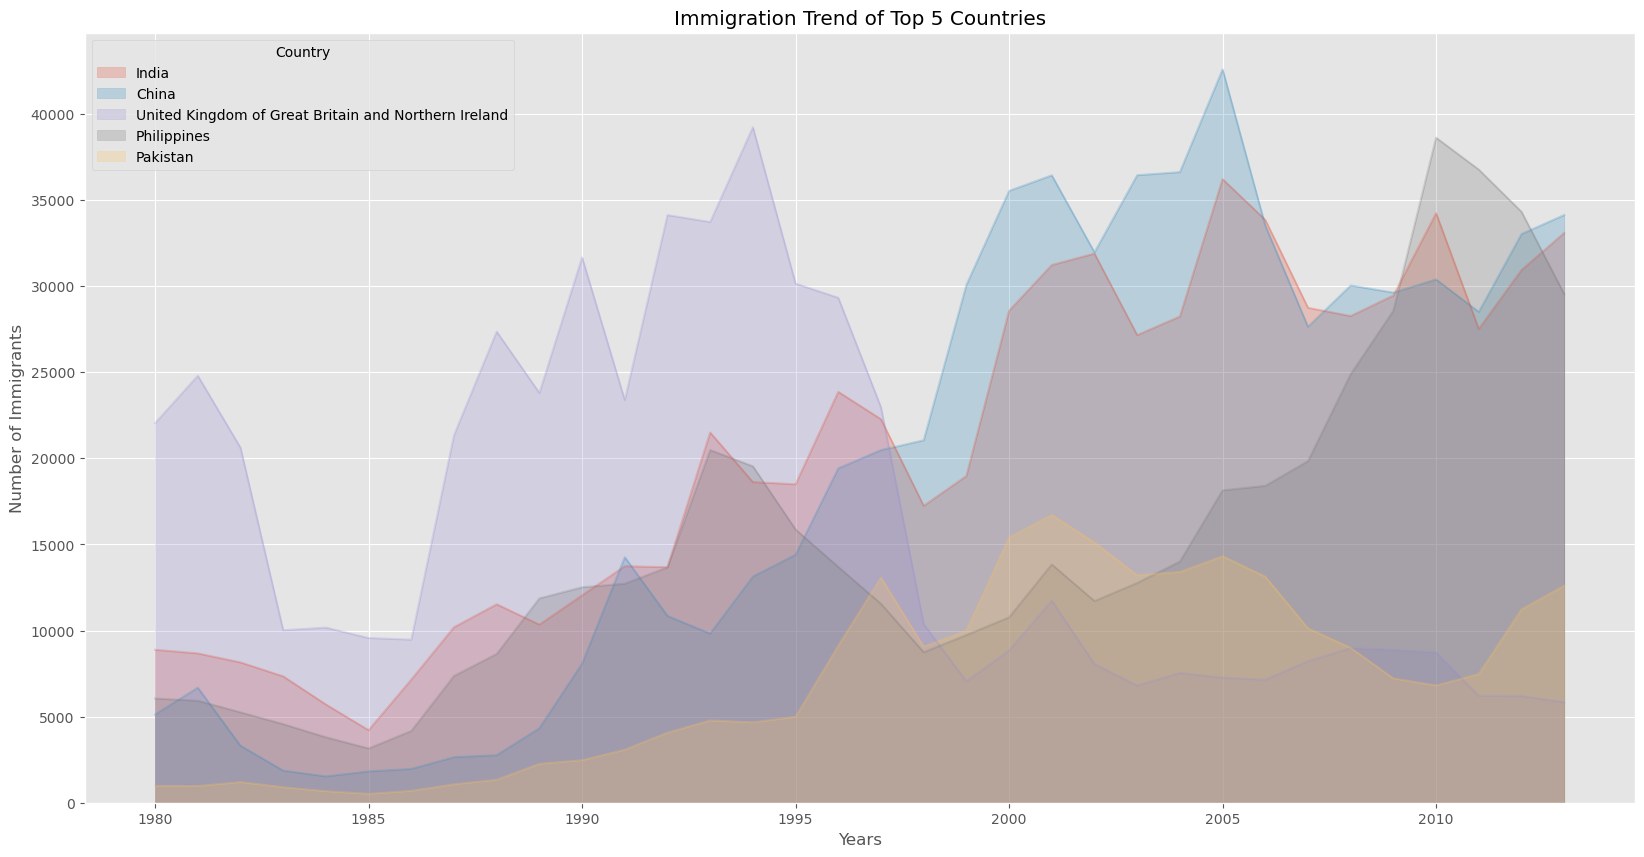

In [10]:
# Area plot (Procedural Method)
df_top5.plot(
    kind='area',
    alpha=0.25,
    stacked=False,
    figsize=(20, 10)
)
plt.title('Immigration Trend of Top 5 Countries')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')
plt.show()

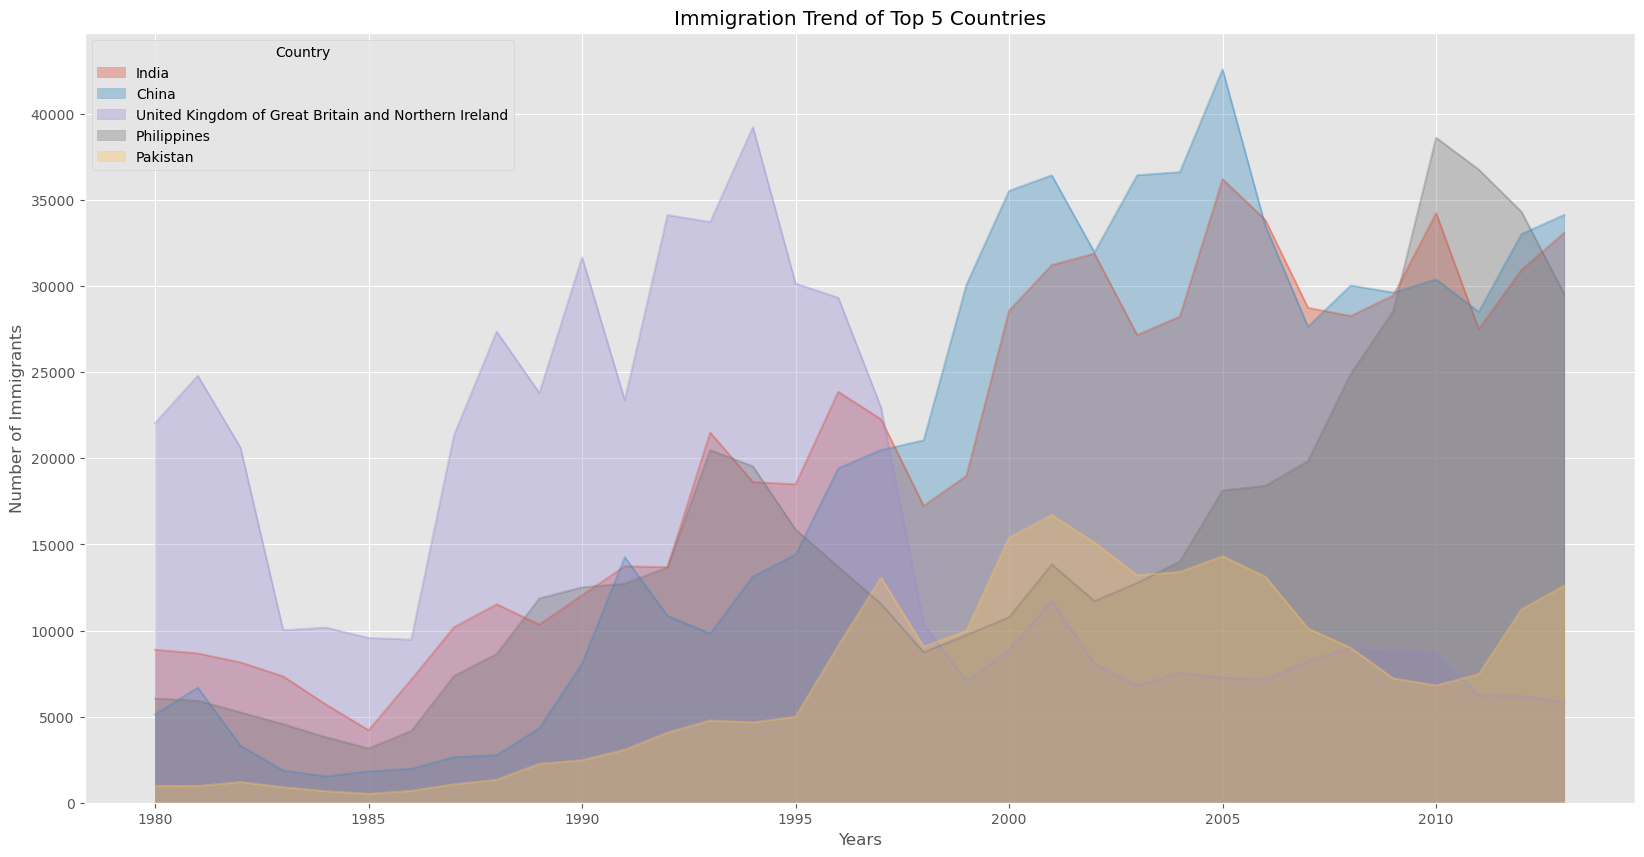

In [11]:
# Area plot (Object Oriented Method)
ax = df_top5.plot(kind='area', alpha=0.35, stacked=False, figsize=(20, 10))
ax.set_title('Immigration Trend of Top 5 Countries')
ax.set_ylabel('Number of Immigrants')
ax.set_xlabel('Years')
plt.show()

### 1.2 Histogram <a id="histogram"></a>

A histogram is a way of representing the *frequency* distribution of numeric dataset. The way it works is it partitions the x-axis into *bins*, assigns each data point in our dataset to a bin, and then counts the number of data points that have been assigned to each bin. So the y-axis is the frequency or the number of data points in each bin. Note that we can change the bin size and usually one needs to tweak it so that the distribution is displayed nicely.

In [12]:
df_can['2013'].head()

Country
India                                                   33087
China                                                   34129
United Kingdom of Great Britain and Northern Ireland     5827
Philippines                                             29544
Pakistan                                                12603
Name: 2013, dtype: int64

In [13]:
count, bin_edges = np.histogram(df_can['2013'])

print(bin_edges)           # bin ranges, default = 10 bins
print('\n', count)         # frequency count

[    0.   3412.9  6825.8 10238.7 13651.6 17064.5 20477.4 23890.3 27303.2
 30716.1 34129. ]

 [178  11   1   2   0   0   0   0   1   2]


By default, the `histrogram` method breaks up the dataset into 10 bins. The figure below summarizes the bin ranges and the frequency distribution of immigration in 2013. We can see that in 2013:
- 178 countries contributed between 0 to 3412.9 immigrants 
- 11 countries contributed between 3412.9 to 6825.8 immigrants
- 1 country contributed between 6285.8 to 10238.7 immigrants, and so on..


| Bin             | 1       | 2       | 3        | 4       | 5       | 6       | 7       | 8       | 9       | 10      |
|-----------------|---------|---------|----------|---------|---------|---------|---------|---------|---------|---------|
| Bin Range       | 0 to 3412.9 | 3412.9 to 6825.8 | 6825.8 to 10238.7 | 10238.7 to 13651.6 | 13651.6 to 17064.5 | 17064.5 to 20477.4 | 20477.4 to 23890.3 | 23890.3 to 27303.2 | 27303.2 to 30716.1 | 30716.1 to 34129 |
| Frequency Count | 178     | 11      | 1        | 2       | 0       | 0       | 0       | 1       | 2       | 0       |



The x-axis labels match with the bin size by passing in a `xticks` keyword that contains the list of the bin sizes:

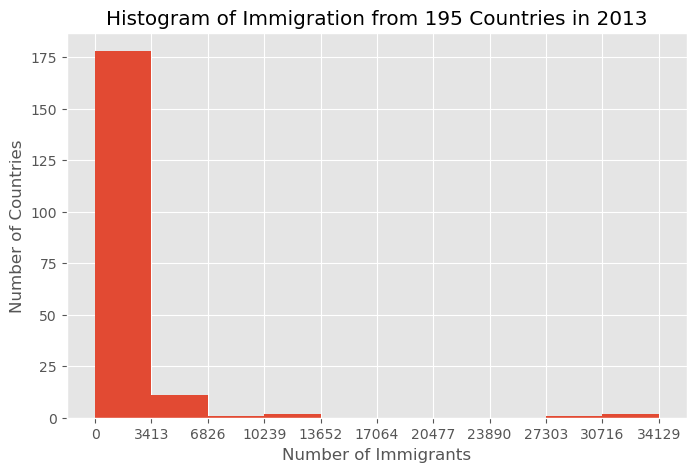

In [14]:
# Histogram
df_can['2013'].plot(kind='hist', figsize=(8, 5), xticks=bin_edges)
plt.title('Histogram of Immigration from 195 Countries in 2013') 
plt.ylabel('Number of Countries') 
plt.xlabel('Number of Immigrants')
plt.show()

Now, We want to check the immigration dristribution for some countries.

In [15]:
df_t = df_can.loc[['Denmark', 'Norway', 'Sweden'], years].transpose()
df_t.head()

Country,Denmark,Norway,Sweden
1980,272,116,281
1981,293,77,308
1982,299,106,222
1983,106,51,176
1984,93,31,128


[ 31.          49.46666667  67.93333333  86.4        104.86666667
 123.33333333 141.8        160.26666667 178.73333333 197.2
 215.66666667 234.13333333 252.6        271.06666667 289.53333333
 308.        ]

 [ 5 13 21 14  9 10  5  9  7  3  1  0  0  2  3]


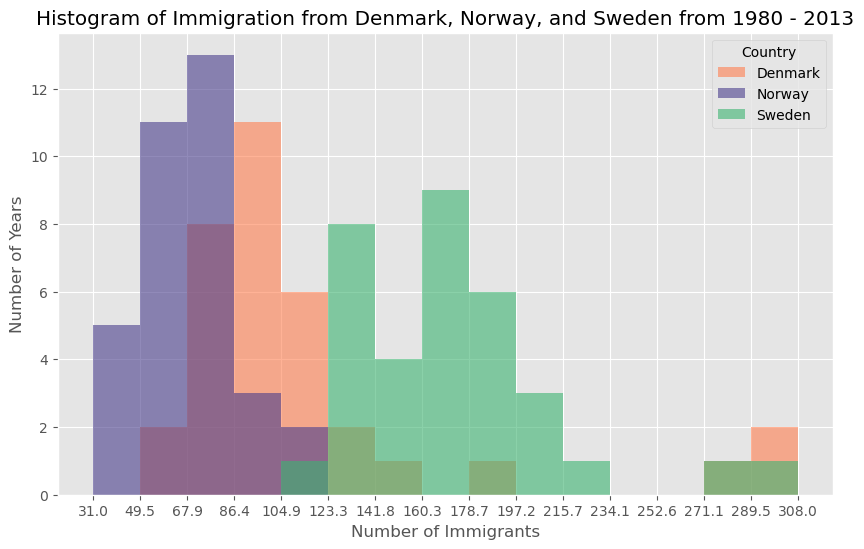

In [16]:
count, bin_edges = np.histogram(df_t, 15)

print(bin_edges)           # bin ranges, default = 10 bins
print('\n', count)         # frequency count

# Un-stacked Histogram
df_t.plot(
    kind ='hist', 
    figsize=(10, 6),
    bins=15,
    alpha=0.6,
    xticks=bin_edges,
    color=['coral', 'darkslateblue', 'mediumseagreen']
)
plt.title('Histogram of Immigration from Denmark, Norway, and Sweden from 1980 - 2013')
plt.ylabel('Number of Years')
plt.xlabel('Number of Immigrants')
plt.show()

> **Tip**: For a full listing of colors available in Matplotlib, run the following code in your python shell:

```python
import matplotlib
for name, hex in matplotlib.colors.cnames.items():
    print(name, hex)
```

If we do no want the plots to overlap each other, we can stack them using the `stacked` paramemter. Let's also adjust the min and max x-axis labels to remove the extra gap on the edges of the plot. We can pass a tuple (min,max) using the `xlim` paramater, as show below.

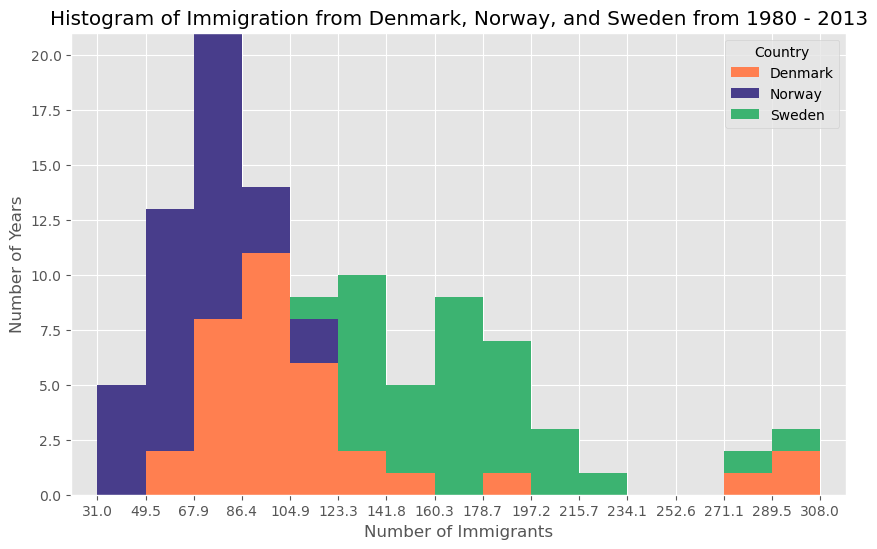

In [17]:
count, bin_edges = np.histogram(df_t, 15)
xmin = bin_edges[0] - 10    # add 10 for aesthetic purposes
xmax = bin_edges[-1] + 10   # add 10 for aesthetic purposes

# Stacked Histogram
df_t.plot(
    kind='hist',
    figsize=(10, 6), 
    bins=15,
    xticks=bin_edges,
    color=['coral', 'darkslateblue', 'mediumseagreen'],
    stacked=True,
    xlim=(xmin, xmax)
)
plt.title('Histogram of Immigration from Denmark, Norway, and Sweden from 1980 - 2013')
plt.ylabel('Number of Years')
plt.xlabel('Number of Immigrants') 
plt.show()

### 1.3 Bar Chart <a id="bar-chart"></a>

A bar plot is a way of representing data where the *length* of the bars represents the magnitude/size of the feature/variable. Bar graphs usually represent numerical and categorical variables grouped in intervals. 

To create a bar plot, we can pass one of two arguments via `kind` parameter in `plot()`:

- `kind=bar` creates a *vertical* bar plot
- `kind=barh` creates a *horizontal* bar plot

**Vertical bar plot**

In vertical bar graphs, the x-axis is used for labelling, and the length of bars on the y-axis corresponds to the magnitude of the variable being measured. Vertical bar graphs are particuarly useful in analyzing time series data. One disadvantage is that they lack space for text labelling at the foot of each bar. 

In [18]:
df_iceland = df_can.loc['Iceland', years]
df_iceland.head()

1980    17
1981    33
1982    10
1983     9
1984    13
Name: Iceland, dtype: object

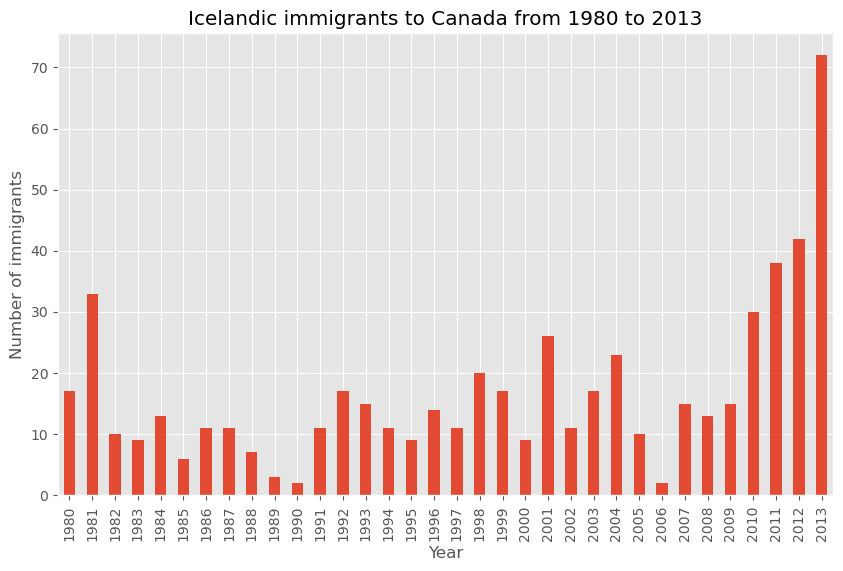

In [19]:
# Bar Plot
df_iceland.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Year') # add to x-label to the plot
plt.ylabel('Number of immigrants') # add y-label to the plot
plt.title('Icelandic immigrants to Canada from 1980 to 2013') # add title to the plot
plt.show()

Let's annotate this on the plot using the `annotate` method of the **scripting layer** or the **pyplot interface**. We will pass in the following parameters:
- `s`: str, the text of annotation.
- `xy`: Tuple specifying the (x,y) point to annotate (in this case, end point of arrow).
- `xytext`: Tuple specifying the (x,y) point to place the text (in this case, start point of arrow).
- `xycoords`: The coordinate system that xy is given in - 'data' uses the coordinate system of the object being annotated (default).
- `arrowprops`: Takes a dictionary of properties to draw the arrow:
    - `arrowstyle`: Specifies the arrow style, `'->'` is standard arrow.
    - `connectionstyle`: Specifies the connection type. `arc3` is a straight line.
    - `color`: Specifes color of arror.
    - `lw`: Specifies the line width.

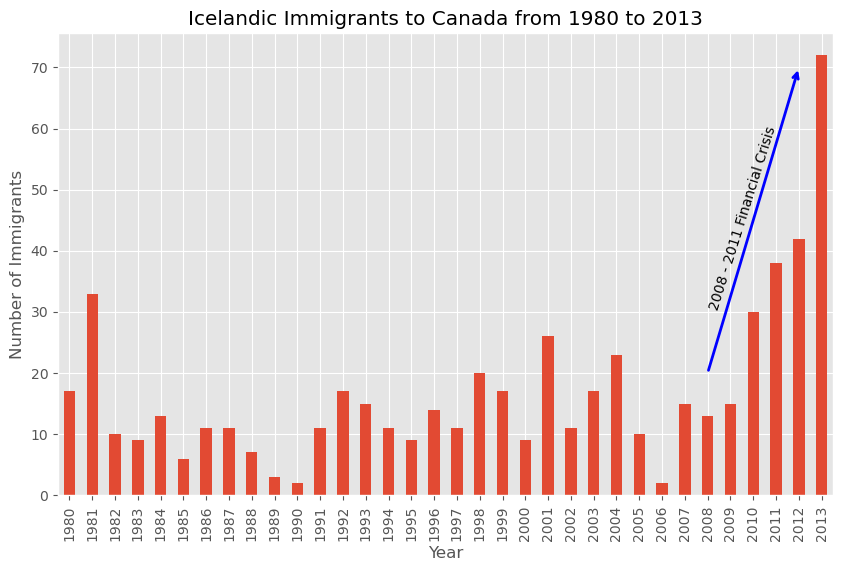

In [20]:
# Bar Plot with Annotations
df_iceland.plot(kind='bar', figsize=(10, 6), rot=90) 
plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.title('Icelandic Immigrants to Canada from 1980 to 2013')

# Annotate arrow
plt.annotate(
    '',                      # s: str. Will leave it blank for no text
    xy=(32, 70),             # place head of the arrow at point (year 2012 , pop 70)
    xytext=(28, 20),         # place base of the arrow at point (year 2008 , pop 20)
    xycoords='data',         # will use the coordinate system of the object being annotated 
    arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='blue', lw=2)
)

# Annotate Text
plt.annotate(
    '2008 - 2011 Financial Crisis', # text to display
    xy=(28, 30),                    # start the text at at point (year 2008 , pop 30)
    rotation=72.5,                  # based on trial and error to match the arrow
    va='bottom',                    # want the text to be vertically 'bottom' aligned
    ha='left',                      # want the text to be horizontally 'left' algned.
)

plt.show()

**Horizontal Bar Plot**

Sometimes it is more practical to represent the data horizontally, especially if you need more room for labelling the bars. In horizontal bar graphs, the y-axis is used for labelling, and the length of bars on the x-axis corresponds to the magnitude of the variable being measured. As you will see, there is more room on the y-axis to  label categetorical variables.

In [21]:
df_can.sort_values(by='Total', ascending=True, inplace=True)
df_top15 = df_can['Total'].tail(15)
df_top15

Country
Romania                                                  93585
Viet Nam                                                 97146
Jamaica                                                 106431
France                                                  109091
Lebanon                                                 115359
Poland                                                  139241
Republic of Korea                                       142581
Sri Lanka                                               148358
Iran (Islamic Republic of)                              175923
United States of America                                241122
Pakistan                                                241600
Philippines                                             511391
United Kingdom of Great Britain and Northern Ireland    551500
China                                                   659962
India                                                   691904
Name: Total, dtype: int64

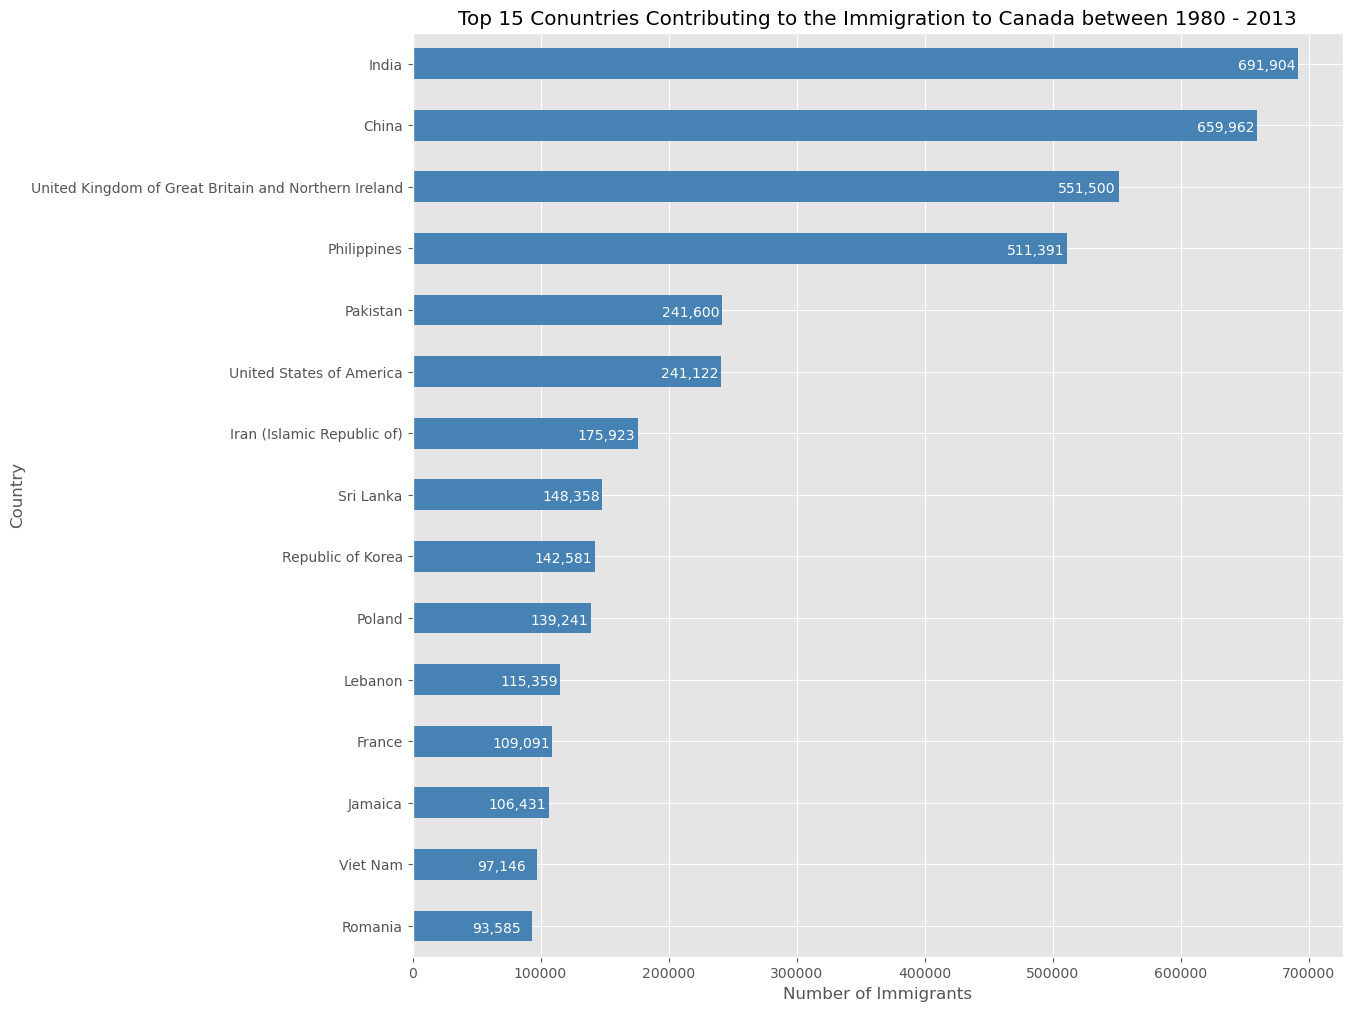

In [22]:
# Horizontal Bar Plot
df_top15.plot(kind='barh', figsize=(12, 12), color='steelblue')
plt.xlabel('Number of Immigrants')
plt.title('Top 15 Conuntries Contributing to the Immigration to Canada between 1980 - 2013')

for index, value in enumerate(df_top15): 
    label = format(int(value), ',')    # format int with commas
    plt.annotate(label, xy=(value - 47000, index - 0.10), color='white')
    
plt.show()

## 2. Intermediate Plots <a id="intermediate-plots"></a>

### 2.1 Pie Chart <a id="pie-chart"></a> 
A `pie chart` is a circualr graphic that displays numeric proportions by dividing a circle (or pie) into proportional slices. You are most likely already familiar with pie charts as it is widely used in business and media. We can create pie charts in Matplotlib by passing in the `kind=pie` keyword.

#### Step 1: Gather data. 

We will use *pandas* `groupby` method to summarize the immigration data by `Continent`. The general process of `groupby` involves the following steps:

1. **Split:** Splitting the data into groups based on some criteria.
2. **Apply:** Applying a function to each group independently:
       .sum()
       .count()
       .mean() 
       .std() 
       .aggregate()
       .apply()
       .etc..
3. **Combine:** Combining the results into a data structure.

![Groupby](../images/groupby.png)

In [23]:
print(type(df_can.groupby('Continent')))

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>


In [24]:
df_continents = df_can.groupby(by=['Continent']).sum(numeric_only=True)
df_continents.head()

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Continent,,,,,,,,,,,,,,,,,,,,,
Africa,3951,4363,3819,2671,2639,2650,3782,7494,7552,9894,...,27523,29188,28284,29890,34534,40892,35441,38083,38543,618948
Asia,31025,34314,30214,24696,27274,23850,28739,43203,47454,60256,...,159253,149054,133459,139894,141434,163845,146894,152218,155075,3317794
Europe,39760,44802,42720,24638,22287,20844,24370,46698,54726,60893,...,35955,33053,33495,34692,35078,33425,26778,29177,28691,1410947
Latin America and the Caribbean,13081,15215,16769,15427,13678,15171,21179,28471,21924,25060,...,24747,24676,26011,26547,26867,28818,27856,27173,24950,765148
Northern America,9378,10030,9074,7100,6661,6543,7074,7705,6469,6790,...,8394,9613,9463,10190,8995,8142,7677,7892,8503,241142


#### Step 2: Plot the data.
We will pass in `kind = 'pie'` keyword, along with the following additional parameters:
- `autopct` -  is a string or function used to label the wedges with their numeric value. The label will be placed inside the wedge. If it is a format string, the label will be `fmt%pct`.
- `startangle` - rotates the start of the pie chart by angle degrees counterclockwise from the x-axis.
- `shadow` - Draws a shadow beneath the pie (to give a 3D feel).

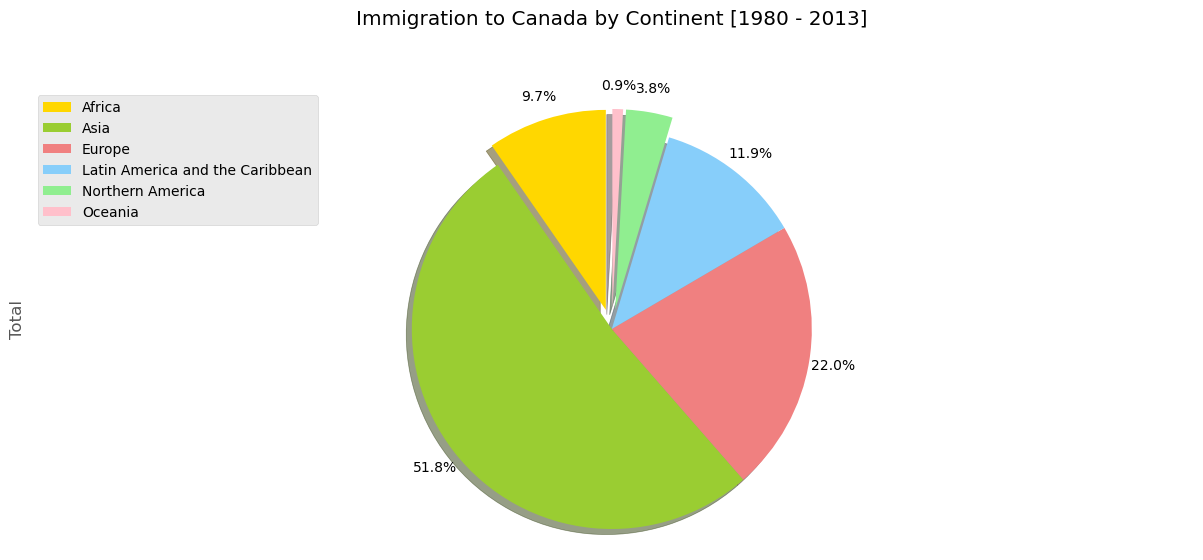

In [25]:
colors_list = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue', 'lightgreen', 'pink']
explode_list = [0.1, 0, 0, 0, 0.1, 0.1]

df_continents['Total'].plot(
    kind='pie',
    figsize=(15, 6),
    autopct='%1.1f%%',   # add in percentages
    startangle=90,       # start angle 90° (Africa)
    shadow=True,         # add shadow  
    labels=None,         # turn off labels on pie chart
    pctdistance=1.12,    # the ratio between the center of each pie slice and the start of the text generated by autopct 
    colors=colors_list,  # add custom colors
    explode=explode_list # 'explode' lowest 3 continents   
)
plt.title('Immigration to Canada by Continent [1980 - 2013]', y=1.12) 
plt.axis('equal') # Sets the pie chart to look like a circle
plt.legend(labels=df_continents.index, loc='upper left') 
plt.show()

### 2.2 Box Plot <a id="box-plot"></a>

A `box plot` is a way of statistically representing the *distribution* of the data through five main dimensions: 

- **Minimun:** Smallest number in the dataset.
- **First quartile:** Middle number between the `minimum` and the `median`.
- **Second quartile (Median):** Middle number of the (sorted) dataset.
- **Third quartile:** Middle number between `median` and `maximum`.
- **Maximum:** Highest number in the dataset.

![Box Plot](../images/box_plot.png)

In [26]:
df_japan = df_can.loc[['Japan'], years].transpose()
df_japan.head()

Country,Japan
1980,701
1981,756
1982,598
1983,309
1984,246


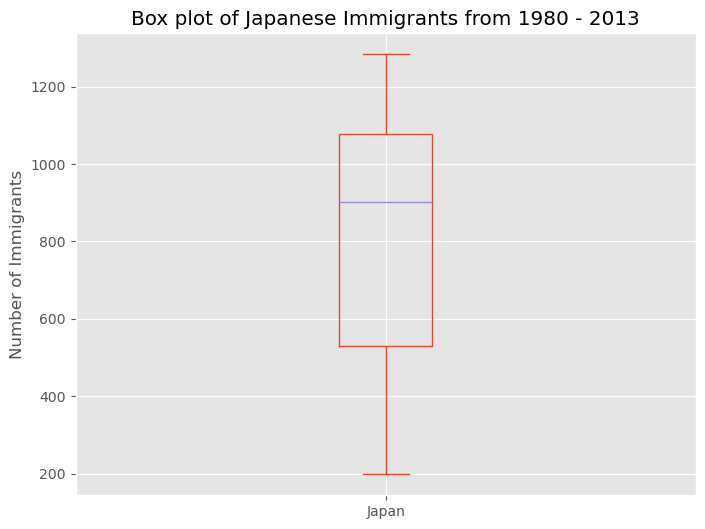

Country,Japan
count,34.000000
mean,814.911765
std,337.219771
min,198.000000
25%,529.000000
50%,902.000000
75%,1079.000000
max,1284.000000


In [27]:
df_japan.plot(kind='box', figsize=(8, 6))
plt.title('Box plot of Japanese Immigrants from 1980 - 2013')
plt.ylabel('Number of Immigrants')
plt.show()

df_japan.describe()

In [28]:
df_ci = df_can.loc[['China', 'India'], years].transpose()
df_ci.head()

Country,China,India
1980,5123,8880
1981,6682,8670
1982,3308,8147
1983,1863,7338
1984,1527,5704


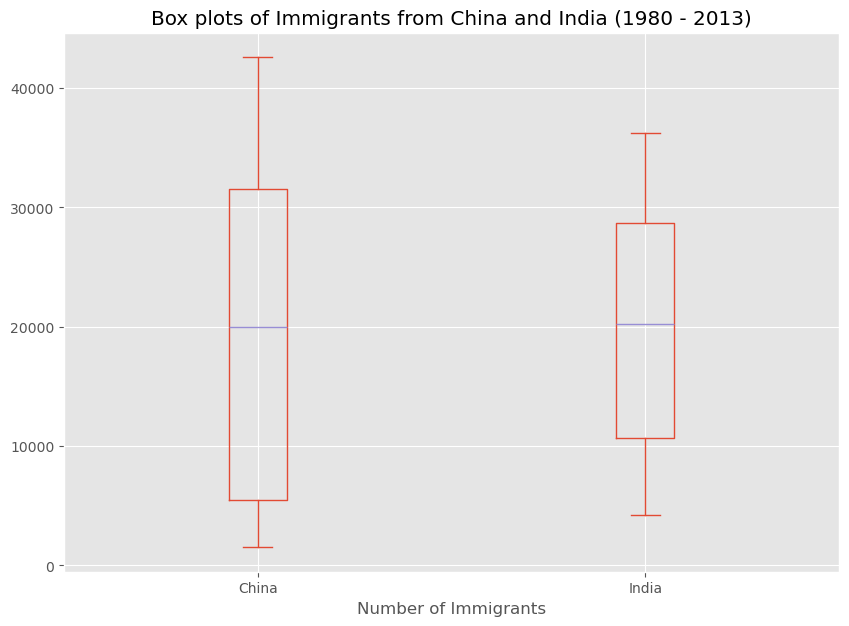

Country,China,India
count,34.000000,34.000000
mean,19410.647059,20350.117647
std,13568.230790,10007.342579
min,1527.000000,4211.000000
25%,5512.750000,10637.750000
50%,19945.000000,20235.000000
75%,31568.500000,28699.500000
max,42584.000000,36210.000000


In [29]:
df_ci.plot(kind='box', figsize=(10, 7))
plt.title('Box plots of Immigrants from China and India (1980 - 2013)')
plt.xlabel('Number of Immigrants')
plt.show()

df_ci.describe()

If you prefer to create horizontal box plots, you can pass the `vert` parameter in the **plot** function and assign it to *False*. You can also specify a different color in case you are not a big fan of the default red color.

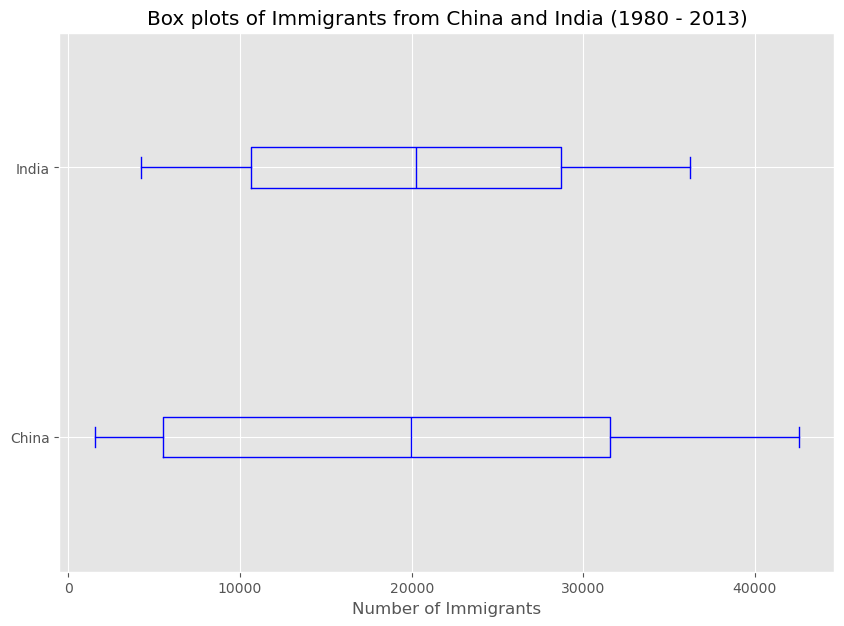

In [30]:
df_ci.plot(kind='box', figsize=(10, 7), color='blue', vert=False)
plt.title('Box plots of Immigrants from China and India (1980 - 2013)')
plt.xlabel('Number of Immigrants')
plt.show()

#### Example:
1. Get the top 15 countries based on Total immigrant population. Name the dataframe **df_top15**.
2. Create a new dataframe which contains the aggregate for each decade. One way to do that:
   - Create a list of all years in decades 80's, 90's, and 00's.
   - Slice the original dataframe df_can to create a series for each decade and sum across all years for each country.
   - Merge the three series into a new data frame. Call your dataframe **new_df**.
3. Plot the box plots.

In [31]:
df_top15 = df_can.sort_values(['Total'], ascending=False, axis=0).head(15)
df_top15

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
India,Asia,Southern Asia,Developing regions,8880,8670,8147,7338,5704,4211,7150,...,36210,33848,28742,28261,29456,34235,27509,30933,33087,691904
China,Asia,Eastern Asia,Developing regions,5123,6682,3308,1863,1527,1816,1960,...,42584,33518,27642,30037,29622,30391,28502,33024,34129,659962
United Kingdom of Great Britain and Northern Ireland,Europe,Northern Europe,Developed regions,22045,24796,20620,10015,10170,9564,9470,...,7258,7140,8216,8979,8876,8724,6204,6195,5827,551500
Philippines,Asia,South-Eastern Asia,Developing regions,6051,5921,5249,4562,3801,3150,4166,...,18139,18400,19837,24887,28573,38617,36765,34315,29544,511391
Pakistan,Asia,Southern Asia,Developing regions,978,972,1201,900,668,514,691,...,14314,13127,10124,8994,7217,6811,7468,11227,12603,241600
United States of America,Northern America,Northern America,Developed regions,9378,10030,9074,7100,6661,6543,7074,...,8394,9613,9463,10190,8995,8142,7676,7891,8501,241122
Iran (Islamic Republic of),Asia,Southern Asia,Developing regions,1172,1429,1822,1592,1977,1648,1794,...,5837,7480,6974,6475,6580,7477,7479,7534,11291,175923
Sri Lanka,Asia,Southern Asia,Developing regions,185,371,290,197,1086,845,1838,...,4930,4714,4123,4756,4547,4422,3309,3338,2394,148358
Republic of Korea,Asia,Eastern Asia,Developing regions,1011,1456,1572,1081,847,962,1208,...,5832,6215,5920,7294,5874,5537,4588,5316,4509,142581


In [32]:
years_80s = list(map(str, range(1980, 1990))) 
years_90s = list(map(str, range(1990, 2000))) 
years_00s = list(map(str, range(2000, 2010))) 

df_80s = df_top15.loc[:, years_80s].sum(axis=1, numeric_only=True) 
df_90s = df_top15.loc[:, years_90s].sum(axis=1, numeric_only=True) 
df_00s = df_top15.loc[:, years_00s].sum(axis=1, numeric_only=True)

new_df = pd.DataFrame({'1980s': df_80s, '1990s': df_90s, '2000s':df_00s})
new_df.head()

,1980s,1990s,2000s
Country,,,
India,82154,180395,303591
China,32003,161528,340385
United Kingdom of Great Britain and Northern Ireland,179171,261966,83413
Philippines,60764,138482,172904
Pakistan,10591,65302,127598


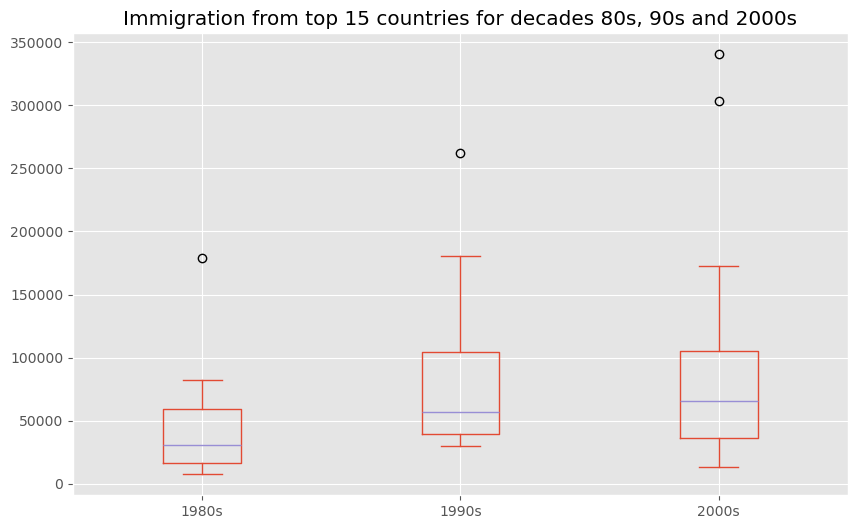

,1980s,1990s,2000s
count,15.000000,15.000000,15.000000
mean,44418.333333,85594.666667,97471.533333
std,44190.676455,68237.560246,100583.204205
min,7613.000000,30028.000000,13629.000000
25%,16698.000000,39259.000000,36101.500000
50%,30638.000000,56915.000000,65794.000000
75%,59183.000000,104451.500000,105505.500000
max,179171.000000,261966.000000,340385.000000


In [33]:
new_df.plot(kind='box', figsize=(10, 6))
plt.title('Immigration from top 15 countries for decades 80s, 90s and 2000s')
plt.show()

new_df.describe()

> Note how the box plot differs from the summary table created. The box plot scans the data and identifies the outliers. In order to be an outlier, the data value must be:
* larger than Q3 by at least 1.5 times the interquartile range (IQR), or,
* smaller than Q1 by at least 1.5 times the IQR.

Let's look at decade 2000s as an example:
* Q1 (25%) = 36,101.5 
* Q3 (75%) = 105,505.5 
* IQR = Q3 - Q1 = 69,404 

Using the definition of outlier, any value that is greater than Q3 by 1.5 times IQR will be flagged as outlier.

Outlier > 105,505.5 + (1.5 * 69,404) 
Outlier > 209,611.5

### 2.3 Scatter Plot <a id="scatter-plot"></a>

A `scatter plot` (2D) is a useful method of comparing variables against each other. `Scatter` plots look similar to `line plots` in that they both map independent and dependent variables on a 2D graph. While the datapoints are connected together by a line in a line plot, they are not connected in a scatter plot. The data in a scatter plot is considered to express a trend. With further analysis using tools like regression, we can mathematically calculate this relationship and use it to predict trends outside the dataset.

In [34]:
df_tot = pd.DataFrame(df_can[years].sum(axis=0))
df_tot.index = map(int, df_tot.index)
df_tot.reset_index(inplace = True)
df_tot.columns = ['year', 'total']
df_tot.head()

,year,total
0,1980,99137
1,1981,110563
2,1982,104271
3,1983,75550
4,1984,73417


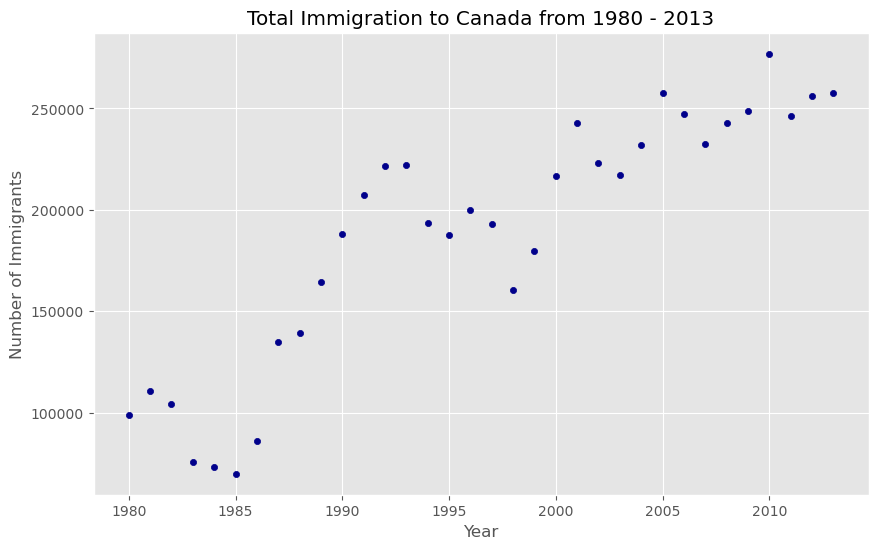

In [35]:
df_tot.plot(kind='scatter', x='year', y='total', figsize=(10, 6), color='darkblue')
plt.title('Total Immigration to Canada from 1980 - 2013')
plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.show()

So let's try to plot a linear line of best fit, and use it to  predict the number of immigrants in 2015.

#### Step 1: Get the equation of line of best fit. 
We will use **Numpy**'s `polyfit()` method by passing in the following:
- `x`: x-coordinates of the data. 
- `y`: y-coordinates of the data. 
- `deg`: Degree of fitting polynomial. 1 = linear, 2 = quadratic, and so on.

In [36]:
x = df_tot['year']      # year on x-axis
y = df_tot['total']     # total on y-axis
fit = np.polyfit(x, y, deg=1)
fit

array([ 5.56709228e+03, -1.09261952e+07])

The output is an array with the polynomial coefficients, highest powers first. Since we are plotting a linear regression `y= a*x + b`, our output has 2 elements `[5.56709228e+03, -1.09261952e+07]` with the the slope in position 0 and intercept in position 1. 

#### Step 2: Plot the regression line on the `scatter plot`.

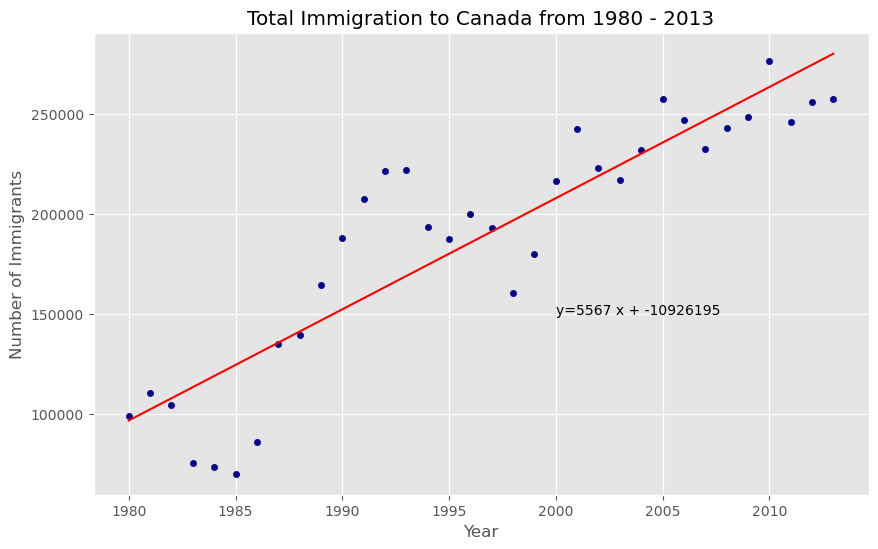

'No. Immigrants = 5567 * Year + -10926195'

In [37]:
df_tot.plot(kind='scatter', x='year', y='total', figsize=(10, 6), color='darkblue')
plt.plot(x, fit[0] * x + fit[1], color='red') # recall that x is the Years
plt.annotate('y={0:.0f} x + {1:.0f}'.format(fit[0], fit[1]), xy=(2000, 150000))

plt.title('Total Immigration to Canada from 1980 - 2013')
plt.xlabel('Year')
plt.ylabel('Number of Immigrants')

plt.show()
# print out the line of best fit
'No. Immigrants = {0:.0f} * Year + {1:.0f}'.format(fit[0], fit[1]) 

### 2.4 Bubble Chart <a id="bubble-chart"></a>

A `bubble plot` is a variation of the `scatter plot` that displays three dimensions of data (x, y, z). The datapoints are replaced with bubbles, and the size of the bubble is determined by the third variable 'z', also known as the weight. In `maplotlib`, we can pass in an array or scalar to the keyword `s` to `plot()`, that contains the weight of each point.

In [38]:
df_can_t = df_can[years].transpose()
df_can_t.index = map(int, df_can_t.index)
df_can_t.index.name = 'Year'
df_can_t.reset_index(inplace=True)
df_can_t.head()

Country,Year,Palau,Western Sahara,Marshall Islands,New Caledonia,San Marino,American Samoa,Tuvalu,Sao Tome and Principe,Vanuatu,...,Poland,Republic of Korea,Sri Lanka,Iran (Islamic Republic of),United States of America,Pakistan,Philippines,United Kingdom of Great Britain and Northern Ireland,China,India
0,1980,0,0,0,0,1,0,0,0,0,...,863,1011,185,1172,9378,978,6051,22045,5123,8880
1,1981,0,0,0,0,0,1,1,0,0,...,2930,1456,371,1429,10030,972,5921,24796,6682,8670
2,1982,0,0,0,0,0,0,0,0,0,...,5881,1572,290,1822,9074,1201,5249,20620,3308,8147
3,1983,0,0,0,0,0,0,0,0,0,...,4546,1081,197,1592,7100,900,4562,10015,1863,7338
4,1984,0,0,0,0,0,0,1,0,0,...,3588,847,1086,1977,6661,668,3801,10170,1527,5704


There are several methods of normalizations in statistics, each with its own use. In this case, we will use `feature scalingn` to bring all values into the range [0,1]. The general formula is:

$$
X' = \frac{X - \min(X)}{\max(X) - \min(X)}
$$

where *`X`* is an original value, *`X'`* is the normalized value. The formula sets the max value in the dataset to 1, and sets the min value to 0. The rest of the datapoints are scaled to a value between 0-1 accordingly.


In [39]:
# Normalize Brazil data
norm_brazil = (df_can_t['Brazil'] - df_can_t['Brazil'].min()) / (df_can_t['Brazil'].max() - df_can_t['Brazil'].min())

# Normalize Argentina data
norm_argentina = (df_can_t['Argentina'] - df_can_t['Argentina'].min()) / (df_can_t['Argentina'].max() - df_can_t['Argentina'].min())

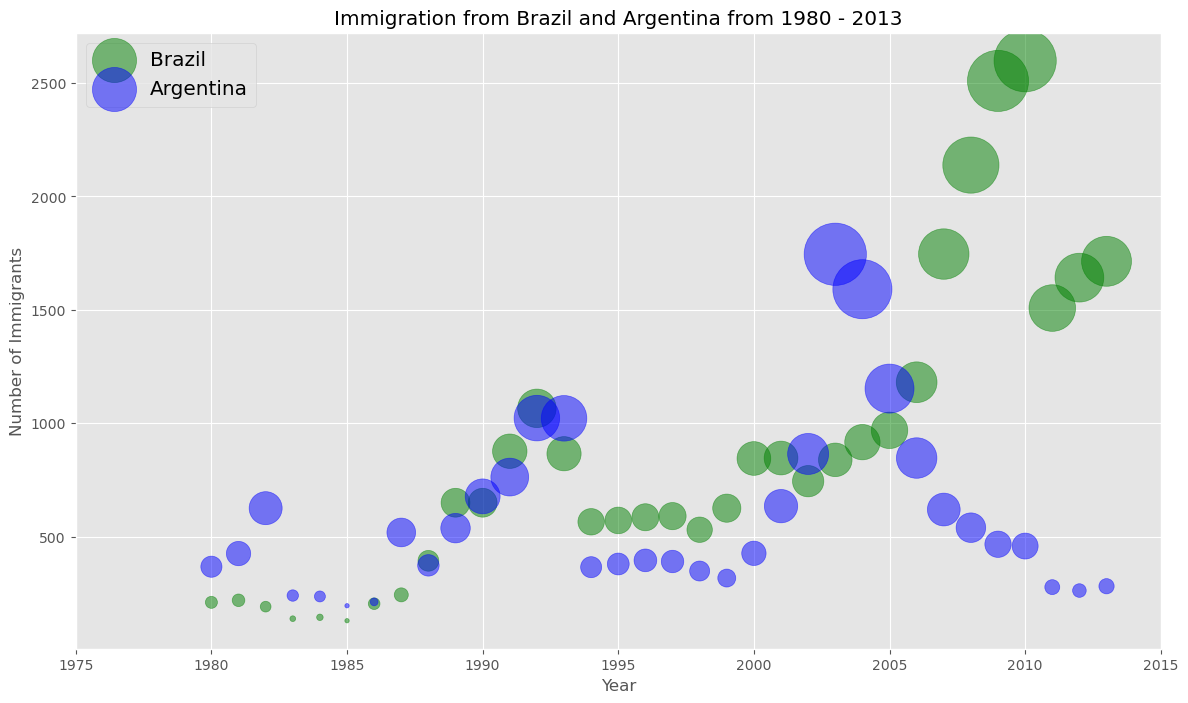

In [40]:
# Brazil
ax0 = df_can_t.plot(
    kind='scatter',
    x='Year',
    y='Brazil',
    figsize=(14, 8),
    alpha=0.5,                  # transparency
    color='green',
    s=norm_brazil * 2000 + 10,  # pass in weights 
    xlim=(1975, 2015)
)

# Argentina
ax1 = df_can_t.plot(
    kind='scatter',
    x='Year',
    y='Argentina',
    alpha=0.5,
    color="blue",
    s=norm_argentina * 2000 + 10,
    ax = ax0
)

ax0.set_ylabel('Number of Immigrants')
ax0.set_title('Immigration from Brazil and Argentina from 1980 - 2013')
ax0.legend(['Brazil', 'Argentina'], loc='upper left', fontsize='x-large')
plt.show()

The size of the bubble corresponds to the magnitude of immigrating population for that year, compared to the 1980 - 2013 data. The larger the bubble, the more immigrants in that year.

From the plot above, we can see a corresponding increase in immigration from Argentina during the 1998 - 2002 great depression. We can also observe a similar spike around 1985 to 1993. In fact, Argentina had suffered a great depression from 1974 - 1990, just before the onset of 1998 - 2002 great depression. 

On a similar note, Brazil suffered the *Samba Effect* where the Brazilian real (currency) dropped nearly 35% in 1999. There was a fear of a South American financial crisis as many South American countries were heavily dependent on industrial exports from Brazil. The Brazilian government subsequently adopted an austerity program, and the economy slowly recovered over the years, culminating in a surge in 2010. The immigration data reflect these events.

## 3. Advanced Plots <a id="advanced-plots"></a>

### 3.1 Waffle Chart <a id="waffle-chart"></a>

A `waffle chart` is an interesting visualization that is normally created to display progress toward goals. It is commonly an effective option when you are trying to add interesting visualization features to a visual that consists mainly of cells, such as an Excel dashboard.

In [41]:
df_dsn = df_can.loc[['Denmark', 'Norway', 'Sweden'], :]
df_dsn

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Denmark,Europe,Northern Europe,Developed regions,272,293,299,106,93,73,93,...,62,101,97,108,81,92,93,94,81,3901
Norway,Europe,Northern Europe,Developed regions,116,77,106,51,31,54,56,...,57,53,73,66,75,46,49,53,59,2327
Sweden,Europe,Northern Europe,Developed regions,281,308,222,176,128,158,187,...,205,139,193,165,167,159,134,140,140,5866


**Step 1.** The first step into creating a waffle chart is determing the proportion of each category with respect to the total.

**Step 2.** The second step is defining the overall size of the `waffle` chart.

**Step 3.** The third step is using the proportion of each category to determe it respective number of tiles

**Step 4.** The fourth step is creating a matrix that resembles the `waffle` chart and populating it.

**Step 5.** Map the `waffle` chart matrix into a visual.

Denmark: 0.32255663965602777
Norway: 0.1924094592359848
Sweden: 0.48503390110798744

Total number of tiles is  400 

Denmark: 129
Norway: 77
Sweden: 194

Waffle chart populated!
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3.
  3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3.
  3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3.
  3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3.
  3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3.
  3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3.
  3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3. 3

<Figure size 640x480 with 0 Axes>

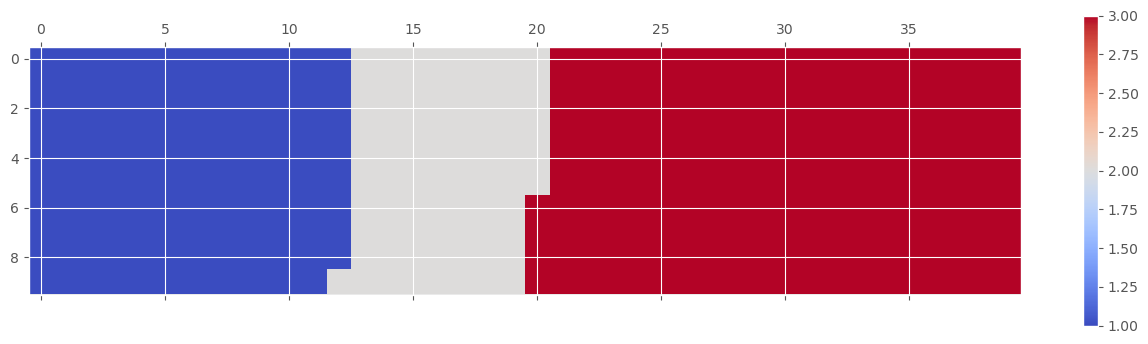

In [42]:
# Step 1: Proportions
total_values = sum(df_dsn['Total'])
category_proportions = [(float(value) / total_values) for value in df_dsn['Total']]

for i, proportion in enumerate(category_proportions):
    print (df_dsn.index.values[i] + ': ' + str(proportion))
    
# Step 2: Overall Size of the chart
width = 40 # width of chart
height = 10 # height of chart
total_num_tiles = width * height # total number of tiles
print ('\nTotal number of tiles is ', total_num_tiles, '\n')

# Step3: Compute the number of tiles for each catagory
tiles_per_category = [round(proportion * total_num_tiles) for proportion in category_proportions]

for i, tiles in enumerate(tiles_per_category):
    print (df_dsn.index.values[i] + ': ' + str(tiles))
    
    
# Step 4: Initialize the waffle chart as an empty matrix
waffle_chart = np.zeros((height, width))
category_index = 0
tile_index = 0

for col in range(width):
    for row in range(height):
        tile_index += 1
        # if the number of tiles populated for the current category is equal to its corresponding allocated tiles...
        if tile_index > sum(tiles_per_category[0:category_index]):
            category_index += 1       
            
        waffle_chart[row, col] = category_index
        
print('\nWaffle chart populated!')
print(waffle_chart)

# Step 5: Figure object
fig = plt.figure()
colormap = plt.cm.coolwarm
plt.matshow(waffle_chart, cmap=colormap)
plt.colorbar()
plt.show()

> *Note*: The importance of functions!

Now it would very inefficient to repeat these seven steps every time we wish to create a `waffle` chart. So let's combine all seven steps into one function called *create_waffle_chart*. This function would take the following parameters as input:

1. **categories**: Unique categories or classes in dataframe.
2. **values**: Values corresponding to categories or classes.
3. **height**: Defined height of waffle chart.
4. **width**: Defined width of waffle chart.
5. **colormap**: Colormap class
6. **value_sign**: In order to make our function more generalizable, we will add this parameter to address signs that could be associated with a value such as %, $, and so on. **value_sign** has a default value of empty string.

In [43]:
def create_waffle_chart(categories, values, height, width, colormap, value_sign=''):
    """
    Creates a waffle chart visualization using matplotlib.
    
    Parameters:
        categories (list): A list of category names.
        values (list): A list of values corresponding to each category.
        height (int): The height of the waffle chart in terms of tiles.
        width (int): The width of the waffle chart in terms of tiles.
        colormap (matplotlib.colors.Colormap): The colormap to use for the waffle chart.
        value_sign (str, optional): A sign to append or prepend to each value in the legend 
                                    (e.g., '%' or '$'). Defaults to an empty string.
    
    Returns:
        None: Displays the waffle chart with a legend.
    
    Notes:
        - The function creates a waffle chart by dividing a grid into tiles that represent
          the proportions of each category.
        - It generates a legend based on the input categories and values.
        - The function does not return any value but visualizes the chart using matplotlib.
    """
    
    # Compute the proportion of each category with respect to the total
    total_values = sum(values)
    category_proportions = [(float(value) / total_values) for value in values]

    # Compute the total number of tiles
    total_num_tiles = width * height  # total number of tiles
    print('Total number of tiles is', total_num_tiles)

    # Compute the number of tiles for each category
    tiles_per_category = [round(proportion * total_num_tiles) for proportion in category_proportions]

    # Print out the number of tiles per category
    for i, tiles in enumerate(tiles_per_category):
        print(df_dsn.index.values[i] + ': ' + str(tiles))

    # Initialize the waffle chart as an empty matrix
    waffle_chart = np.zeros((height, width))

    # Define indices to loop through waffle chart
    category_index = 0
    tile_index = 0

    # Populate the waffle chart
    for col in range(width):
        for row in range(height):
            tile_index += 1

            # If the number of tiles populated for the current category
            # is equal to its corresponding allocated tiles...
            if tile_index > sum(tiles_per_category[0:category_index]):
                # ...proceed to the next category
                category_index += 1

            # Set the class value to an integer, which increases with class
            waffle_chart[row, col] = category_index

    # Instantiate a new figure object
    fig = plt.figure()

    # Use matshow to display the waffle chart
    colormap = plt.cm.coolwarm
    plt.matshow(waffle_chart, cmap=colormap)
    plt.colorbar()

    # Get the axis
    ax = plt.gca()

    # Set minor ticks
    ax.set_xticks(np.arange(-.5, (width), 1), minor=True)
    ax.set_yticks(np.arange(-.5, (height), 1), minor=True)

    # Add gridlines based on minor ticks
    ax.grid(which='minor', color='w', linestyle='-', linewidth=2)

    plt.xticks([])
    plt.yticks([])

    # Compute cumulative sum of individual categories to match color schemes between chart and legend
    values_cumsum = np.cumsum(values)
    total_values = values_cumsum.iloc[-1]

    # Create legend
    legend_handles = []
    for i, category in enumerate(categories):
        if value_sign == '%':
            label_str = category + ' (' + str(values.iloc[i]) + value_sign + ')'
        else:
            label_str = category + ' (' + value_sign + str(values.iloc[i]) + ')'

        color_val = colormap(float(values_cumsum.iloc[i]) / total_values)
        legend_handles.append(mpatches.Patch(color=color_val, label=label_str))

    # Add legend to chart
    plt.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=len(categories),
        bbox_to_anchor=(0., -0.2, 0.95, .1)
    )
    
    plt.show()


Now to create a `waffle` chart, all we have to do is call the function `create_waffle_chart`. Let's define the input parameters:

Total number of tiles is 400
Denmark: 129
Norway: 77
Sweden: 194


<Figure size 640x480 with 0 Axes>

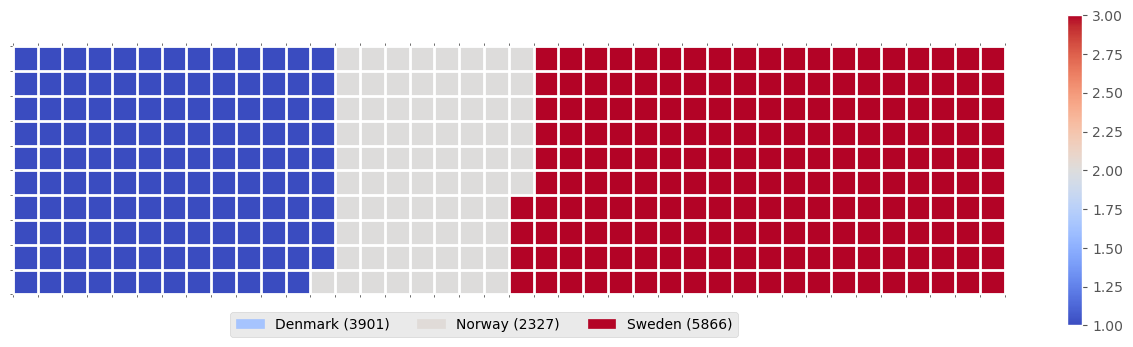

In [44]:
width = 40 # width of chart
height = 10 # height of chart
categories = df_dsn.index.values # categories
values = df_dsn['Total'] # correponding values of categories
colormap = plt.cm.coolwarm # color map class

create_waffle_chart(categories, values, height, width, colormap)

### 3.2 Word Cloud <a id="word-cloud"></a>

`Word` clouds (also known as text clouds or tag clouds) work in a simple way: the more a specific word appears in a source of textual data (such as a speech, blog post, or database), the bigger and bolder it appears in the word cloud.

In [45]:
# Download the file from the URL
url = 'https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DV0101EN/labs/Data_Files/alice_novel.txt'
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Read the file content
    alice_novel = response.text
    print(alice_novel[:500])  # Print the first 500 characters of the novel
else:
    print('Failed to retrieve the file. Status code:', response.status_code)


ï»¿Project Gutenberg's Alice's Adventures in Wonderland, by Lewis Carroll

This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.org


Title: Alice's Adventures in Wonderland

Author: Lewis Carroll

Posting Date: June 25, 2008 [EBook #11]
Release Date: March, 1994
[Last updated: December 20, 20


Next, let's use the stopwords that we imported from `word_cloud`. We use the function *set* to remove any redundant stopwords.

Then, create a word cloud object and generate a word cloud. For simplicity, let's generate a word cloud using only the first 2000 words in the novel.

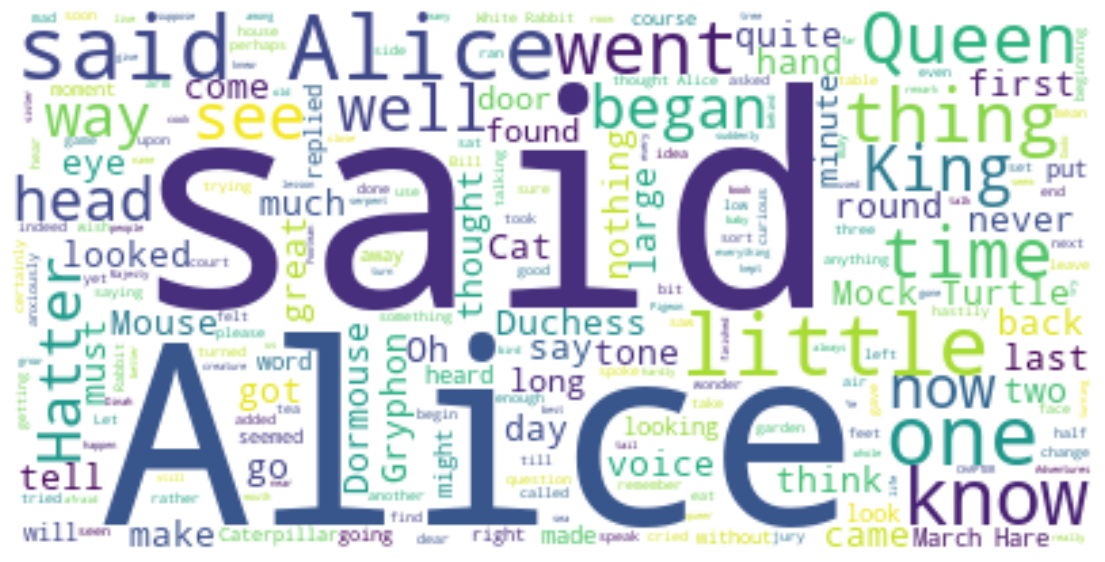

In [46]:
# Set Stopwords
stopwords = set(STOPWORDS)

# Instantiate a word cloud object
alice_wc = WordCloud(
    background_color='white',
    max_words=2000,
    stopwords=stopwords
)

# Generate the word cloud
alice_wc.generate(alice_novel)

# Display the word cloud
fig = plt.figure()
fig.set_figwidth(14) # set width
fig.set_figheight(18) # set height
plt.imshow(alice_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

However, **said** isn't really an informative word. So let's add it to our stopwords and re-generate the cloud.

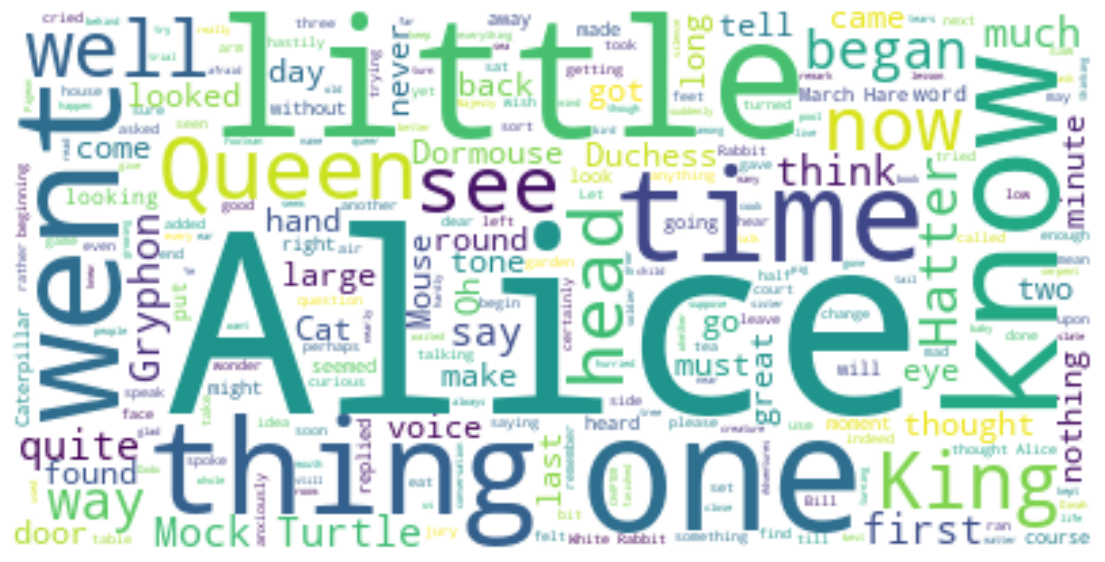

In [47]:
stopwords.add('said') # add the words said to stopwords

# Re-generate the word cloud
alice_wc.generate(alice_novel)

# Display the cloud
fig = plt.figure()
fig.set_figwidth(14) # set width
fig.set_figheight(18) # set height
plt.imshow(alice_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

Using countries with single-word names, let's duplicate each country's name based on how much they contribute to the total immigration.

In [48]:
total_immigration = df_can['Total'].sum()

max_words = 90
word_string = ''
for country in df_can.index.values:
    if len(country.split(' ')) == 1:
        repeat_num_times = int(df_can.loc[country, 'Total'] / float(total_immigration) * max_words)
        word_string = word_string + ((country + ' ') * repeat_num_times)
                        
word_string

'Colombia Morocco Egypt Portugal Guyana Haiti Romania Jamaica France Lebanon Poland Pakistan Pakistan Pakistan Philippines Philippines Philippines Philippines Philippines Philippines Philippines China China China China China China China China China India India India India India India India India India '

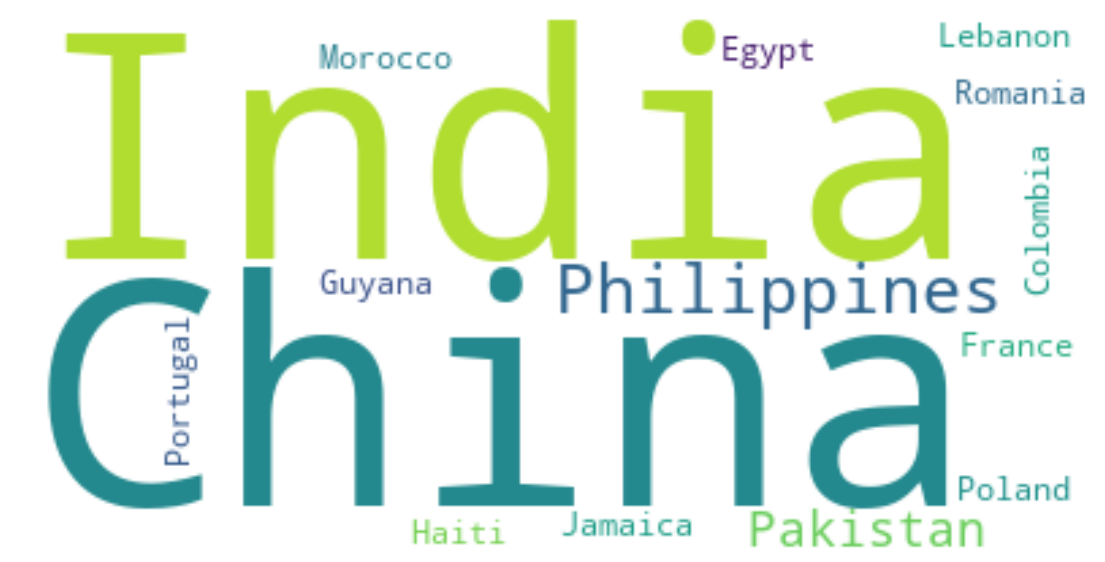

In [49]:
# Create the word cloud
wordcloud = WordCloud(background_color='white').generate(word_string)

# Display the cloud
fig = plt.figure()
fig.set_figwidth(14)
fig.set_figheight(18)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### 3.3 Regression Plot <a id="regression-plot"></a>
In this final section, we will explore *seaborn* and see how efficient it is to create regression lines and fits using this library!

> Seaborn is a Python visualization library based on matplotlib. It provides a high-level interface for drawing attractive statistical graphics. You can learn more about *seaborn* by following this [link](https://seaborn.pydata.org/) and more about *seaborn* regression plots by following this [link](http://seaborn.pydata.org/generated/seaborn.regplot.html).

Create a new dataframe that stores that total number of landed immigrants to Canada per year from 1980 to 2013.

In [50]:
df_tot = pd.DataFrame(df_can[years].sum(axis=0))
df_tot.index = map(float, df_tot.index)
df_tot.reset_index(inplace=True)
df_tot.columns = ['year', 'total']
df_tot.head()

,year,total
0,1980.0,99137
1,1981.0,110563
2,1982.0,104271
3,1983.0,75550
4,1984.0,73417


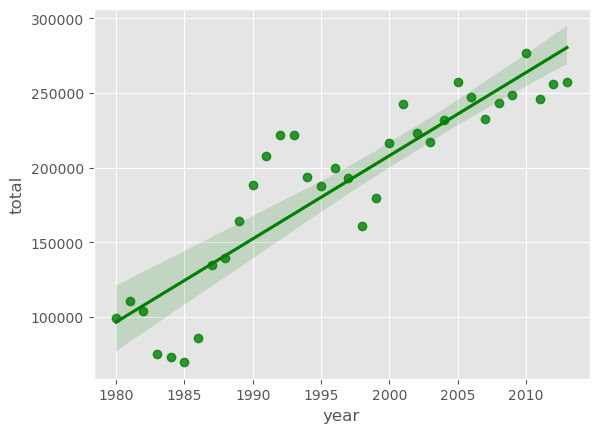

In [51]:
ax = sns.regplot(x='year', y='total', data=df_tot, color='green')

Text(0.5, 1.0, 'Total Immigration to Canada from 1980 - 2013')

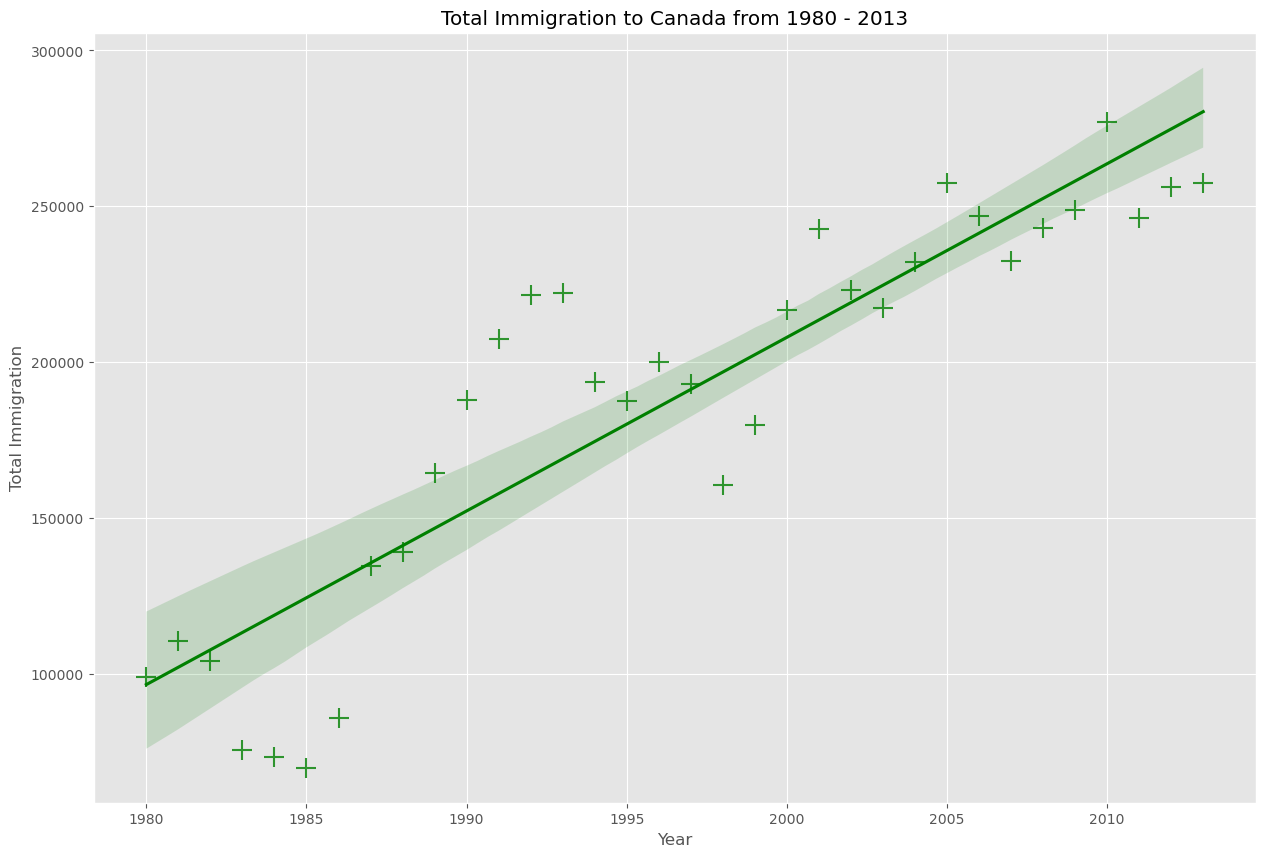

In [52]:
plt.figure(figsize=(15, 10))
ax = sns.regplot(x='year', y='total', data=df_tot, color='green', marker='+', scatter_kws={'s': 200})

ax.set(xlabel='Year', ylabel='Total Immigration') # add x- and y-labels
ax.set_title('Total Immigration to Canada from 1980 - 2013') # add title

---

## 4. Conclusion <a id="conclusion"></a>

In this notebook, we explored a variety of data visualization techniques using **Matplotlib**, **Pandas**, **NumPy**, and **Seaborn**. Each visualization provided valuable insights into the Canadian immigration dataset. Below is a summary of the key takeaways from each section:

### **Basic Plots**
1. **Area Plots:**  
   - Show cumulative trends over time. We observed how immigration to Canada increased steadily from 1980 to 2013.  
   - Area plots are ideal for long-term trend visualization.

2. **Histograms:**  
   - Displayed the distribution of annual immigration counts, allowing us to identify periods of high or low immigration.  
   - Useful for identifying patterns in data spread and frequency.

3. **Bar Charts:**  
   - Helped us compare immigration numbers across different countries and regions.  
   - Bar charts are effective for side-by-side comparisons between categories.

### **Intermediate Plots**
1. **Pie Charts:**  
   - Provided a breakdown of immigration by region, showing the proportional contribution of each region.  
   - Best suited for summarizing proportional data.

2. **Box Plots:**  
   - Revealed the variation and spread in immigration data. We identified outliers and interquartile ranges.  
   - Box plots are useful for identifying data distribution and outliers.

3. **Scatter and Bubble Plots:**  
   - Scatter plots helped us explore relationships between variables, such as yearly immigration trends.  
   - Bubble plots added a third dimension to the analysis, incorporating size to represent additional data points.

### **Advanced Plots**
1. **Waffle Charts:**  
   - Provided a visual alternative to pie charts for illustrating proportions in a more structured layout.  
   - Useful for displaying percentage-based comparisons.

2. **Word Clouds:**  
   - Highlighted the most common countries and regions in the dataset, making it easy to spot dominant contributors to Canadian immigration.  
   - Word clouds are effective for visualizing frequency and emphasis in textual data.

3. **Regression Plots:**  
   - Showed trends and relationships between variables with fitted regression lines. We used **Seaborn** to enhance our analysis with statistical visualization.  
   - Regression plots are essential for identifying linear or non-linear relationships between variables.

---

### **Final Thoughts**  
Data visualization plays a critical role in uncovering patterns, trends, and insights within datasets. By using different plot types, we were able to analyze Canadian immigration data from multiple perspectives. Each visualization technique has strengths depending on the type of data and analysis goals.

Moving forward, combining visualization with statistical analysis and machine learning can further enhance our ability to extract meaningful insights from complex datasets.
